C:\Users\user\AppData\Local\Temp\ipykernel_3672\935400036.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])


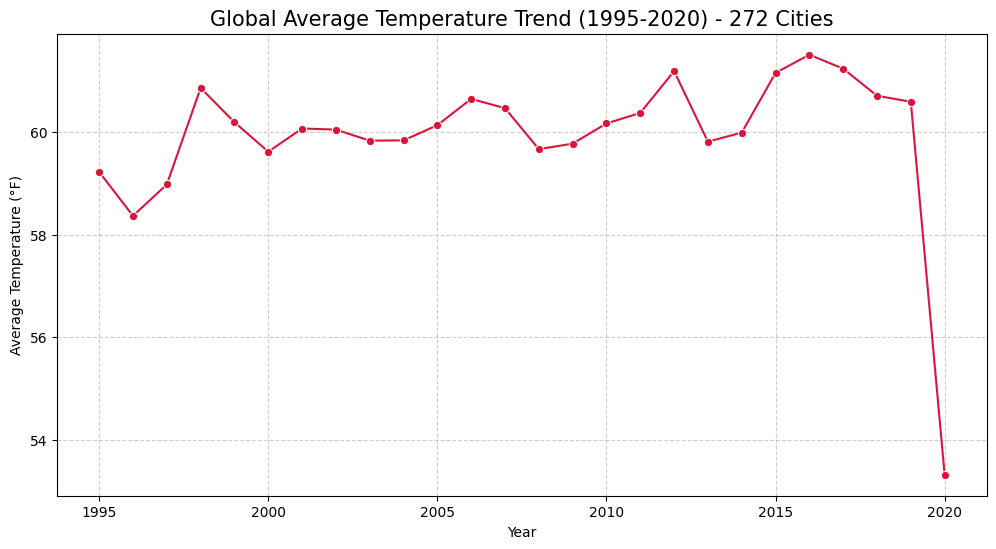

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 정제된 데이터 로드
df = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])

# 2. 연도별 평균 기온 계산
yearly_avg = df.groupby('Year')['AvgTemperature'].mean()

# 3. 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o', color='crimson')
plt.title("Global Average Temperature Trend (1995-2020) - 272 Cities", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°F)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [17]:
import pandas as pd

# 1. 정제 완료된 파일을 다시 불러오기
df_final_clean = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])

# 2. 2020년 데이터만 추출
df_2020 = df_final_clean[df_final_clean['Year'] == 2020]

# 3. 2020년의 월별 데이터 개수 확인
print("--- 2020년 월별 데이터 분포 ---")
print(df_2020['Month'].value_counts().sort_index())

# 4. 2020년의 마지막 기록 날짜 확인
print(f"\n2020년 최종 기록일: {df_2020['date'].max()}")

C:\Users\user\AppData\Local\Temp\ipykernel_3672\159621202.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final_clean = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])


--- 2020년 월별 데이터 분포 ---
Month
1    8364
2    7827
3    8355
4    8071
5    3469
Name: count, dtype: int64

2020년 최종 기록일: 2020-05-13 00:00:00


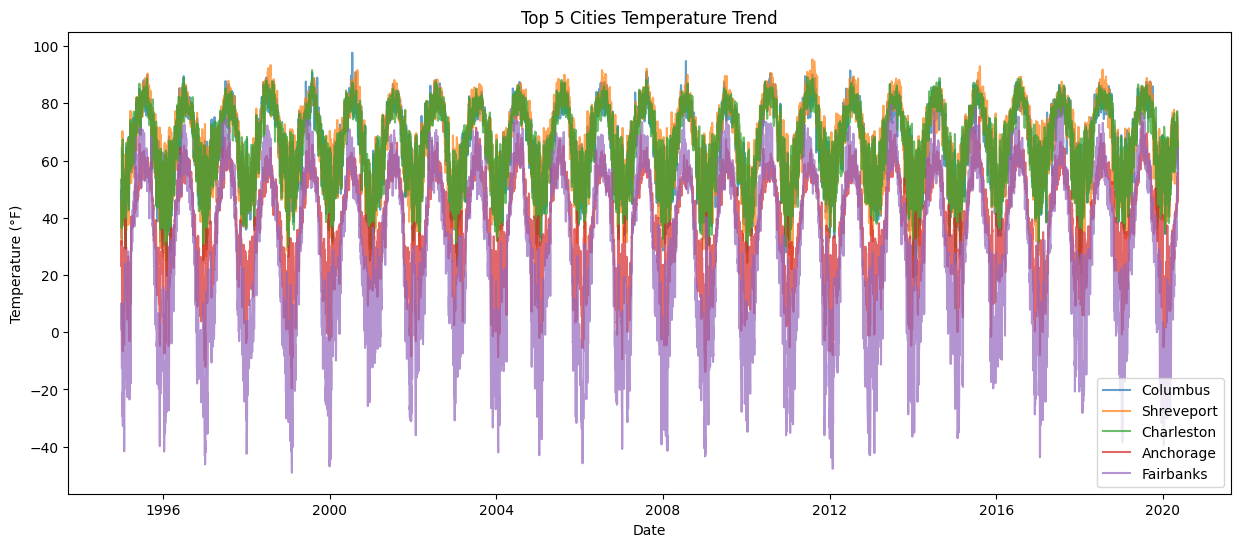

In [18]:
# 도시별 평균 온도 Trend
plt.figure(figsize=(15,6))
top5_cities = df['City'].value_counts().head(5).index
for city in top5_cities:
    city_data = df[df['City']==city]
    plt.plot(city_data['date'], city_data['AvgTemperature'], label=city, alpha=0.7)
plt.title("Top 5 Cities Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.show()

In [19]:
df_final_clean.groupby('Year').size()

Year
1995    96360
1996    97428
1997    97793
1998    96642
1999    98182
2000    98697
2001    98909
2002    97609
2003    98728
2004    99231
2005    99037
2006    98833
2007    98583
2008    98768
2009    98896
2010    99073
2011    98969
2012    99429
2013    99101
2014    99016
2015    99054
2016    98947
2017    99044
2018    97992
2019    97487
2020    36086
dtype: int64

In [27]:
import pandas as pd

# 1. 데이터 로드
df_model = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])

# 2. 연도별 데이터 개수 확인 및 200개 이상만 필터링
table = df_model.groupby(['City', 'Year']).size()
valid = table[table >= 200].reset_index()[['City', 'Year']]

# 3. 우량한 데이터만 병합(Merge)
df_model_final = df_model.merge(valid, on=['City', 'Year'])

print(f"필터링 전 데이터 수: {len(df_model)}")
print(f"필터링 후 데이터 수: {len(df_model_final)}")
print(f"남은 연도 범위: {df_model_final['Year'].min()} ~ {df_model_final['Year'].max()}")

C:\Users\user\AppData\Local\Temp\ipykernel_3672\1445430237.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_model = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])


필터링 전 데이터 수: 2497894
필터링 후 데이터 수: 2460548
남은 연도 범위: 1995 ~ 2019


In [29]:
table = df_final_clean.groupby(['City', 'Year']).size().unstack(fill_value=0)
print(table.to_string())

Year                  1995  1996  1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020
City                                                                                                                                                                            
Abidjan                364   363   358   361   326   349   360   293   301   349   365   364   364   363   364   365   351   366   365   364   364   363   365   361   360   134
Abilene                365   357   365   361   364   366   365   361   363   366   365   365   363   363   364   365   365   366   365   365   364   366   365   365   365   134
Abu Dhabi              365   366   365   361   364   366   365   361   365   366   365   364   364   364   364   365   365   366   365   364   364   362   365   361   359   131
Akron Canton           365   366   365   361   364   366   365   360   363   366   365   365   364   364   364   36

In [22]:
table[2020].value_counts()

2020
134    241
133     21
132      2
0        2
131      1
128      1
113      1
119      1
123      1
121      1
Name: count, dtype: int64

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 우리가 만든 '정예 데이터' 불러오기
df = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])

# 2. 연도별 데이터가 200개 이상인 '완전한 해'만 남기기 (마지막에 논의한 필터링)
counts = df.groupby(['City', 'Year']).size().reset_index(name='days')
valid_indices = counts[counts['days'] >= 200][['City', 'Year']]
df_final = df.merge(valid_indices, on=['City', 'Year'])

print(f"분석 준비 완료! 도시 수: {df_final['City'].nunique()}개")

C:\Users\user\AppData\Local\Temp\ipykernel_3672\1048155207.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("city_temperature_final_272.csv", parse_dates=['date'])


분석 준비 완료! 도시 수: 272개


In [ ]:
df_final_clean.groupby('Year')['AvgTemperature'].mean()
df_final_clean.groupby('Month')['AvgTemperature'].mean()

Month
1     43.709833
2     46.351145
3     52.506318
4     59.722414
5     66.687333
6     72.523647
7     75.572411
8     74.790078
9     69.692536
10    61.494250
11    52.650271
12    45.880949
Name: AvgTemperature, dtype: float64

In [31]:
import pandas as pd

# 1. 1995~2019년 데이터만 슬라이싱
df_model = df_final_clean[(df_final_clean["Year"] >= 1995) & (df_final_clean["Year"] <= 2019)].copy()

# 2. 도시별/연도별 데이터 개수 계산
year_counts = df_model.groupby(['City', 'Year']).size().unstack(fill_value=0)

# 3. '우량 연도' 기준 설정 (예: 1년 365일 중 최소 300일 이상 데이터가 있는 경우)
# 이 기준은 분석 목적에 따라 250일 혹은 330일 등으로 조정 가능합니다.
threshold = 300
is_valid_year = year_counts >= threshold

# 4. 모든 연도(1995~2019, 총 25개 연도)가 기준을 통과한 도시만 선택
# all(axis=1)은 행 방향(연도들)으로 모두 True인 것만 골라냅니다.
perfect_cities = is_valid_year.all(axis=1)
perfect_city_list = perfect_cities[perfect_cities == True].index.tolist()

# 5. 최종 데이터셋 생성
df_final_modeling = df_model[df_model["City"].isin(perfect_city_list)].copy()

print(f"--- [최종 필터링 결과] ---")
print(f"기준 미달로 제외된 도시 수: {len(year_counts) - len(perfect_city_list)}개")
print(f"최종 살아남은 '정예' 도시 수: {len(perfect_city_list)}개")
print(f"최종 데이터 행 수: {len(df_final_modeling)}행")

# 제외된 도시들이 궁금하다면?
dropped_cities = perfect_cities[perfect_cities == False].index.tolist()
print(f"\n제외된 도시 예시: {dropped_cities[:10]}...")

--- [최종 필터링 결과] ---
기준 미달로 제외된 도시 수: 28개
최종 살아남은 '정예' 도시 수: 244개
최종 데이터 행 수: 2219649행

제외된 도시 예시: ['Abidjan', 'Ashabad', 'Bangui', 'Belize City', 'Bishkek', 'Brazzaville', 'Bridgetown', 'Colombo', 'Cotonou', 'Dar Es Salaam']...


In [32]:
table = df_final_clean.groupby(['City', 'Year']).size().unstack(fill_value=0)
print(table.to_string())

Year                  1995  1996  1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020
City                                                                                                                                                                            
Abidjan                364   363   358   361   326   349   360   293   301   349   365   364   364   363   364   365   351   366   365   364   364   363   365   361   360   134
Abilene                365   357   365   361   364   366   365   361   363   366   365   365   363   363   364   365   365   366   365   365   364   366   365   365   365   134
Abu Dhabi              365   366   365   361   364   366   365   361   365   366   365   364   364   364   364   365   365   366   365   364   364   362   365   361   359   131
Akron Canton           365   366   365   361   364   366   365   360   363   366   365   365   364   364   364   36

In [ ]:
import pandas as pd

# 1. 1995~2019년 데이터만 슬라이싱
df_target = df_final_clean[(df_final_clean["Year"] >= 1995) & (df_final_clean["Year"] <= 2019)].copy()

# 2. 도시별/연도별 데이터 개수 계산
table = df_target.groupby(['City', 'Year']).size().unstack(fill_value=0)

# 3. '합격' 기준 설정 (모든 연도가 300일 이상인 도시만 추출)
threshold = 300
is_perfect_city = (table >= threshold).all(axis=1)
perfect_city_list = is_perfect_city[is_perfect_city == True].index

# 4. 합격한 도시들의 데이터만 모은 '최종 분석용' 데이터프레임
df_final_modeling = df_target[df_target["City"].isin(perfect_city_list)].copy()

# 5. 검증용 테이블 생성 (제외된 도시가 없는 상태)
final_table = df_final_modeling.groupby(['City', 'Year']).size().unstack()

print(f"--- [최종 정예 데이터셋 검증] ---")
print(f"합격한 도시 수: {len(perfect_city_list)}개")
print(f"전체 행 수: {len(df_final_modeling)}행")
print("\n--- 도시별/연도별 데이터 개수 (상위 300개 도시 예시) ---")
print(final_table.head(300).to_string())

# 만약 300 미만인 값이 하나라도 있는지 최종 체크 (0이 나와야 정상)
under_threshold = (final_table < threshold).sum().sum()
print(f"\n기준({threshold}일) 미달 데이터 존재 여부: {under_threshold}건")

--- [최종 정예 데이터셋 검증] ---
합격한 도시 수: 244개
전체 행 수: 2219649행

--- 도시별/연도별 데이터 개수 (상위 20개 도시 예시) ---
Year                  1995  1996  1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019
City                                                                                                                                                                      
Abilene                365   357   365   361   364   366   365   361   363   366   365   365   363   363   364   365   365   366   365   365   364   366   365   365   365
Abu Dhabi              365   366   365   361   364   366   365   361   365   366   365   364   364   364   364   365   365   366   365   364   364   362   365   361   359
Akron Canton           365   366   365   361   364   366   365   360   363   366   365   365   364   364   364   365   365   366   365   365   365   366   365   365   365
Albany                 365   366   365   361   364

In [36]:
df_final_modeling.to_csv(
    "city_temperature_model_ready.csv",
    index=False
)

print("모델링용 데이터 저장 완료")
print("도시 수:", df_final_modeling["City"].nunique())
print("행 수:", len(df_final_modeling))

모델링용 데이터 저장 완료
도시 수: 244
행 수: 2219649
